# California House Price Prediction — End-to-End Machine Learning Project

This notebook builds a complete machine learning workflow for predicting house prices using the California housing dataset.

## Project goal
Predict `median_house_value` from district-level housing, population, location, and income features.

## Workflow
1. Load the dataset
2. Understand the data
3. Create train/test split correctly
4. Perform Exploratory Data Analysis (EDA)
5. Prepare data using preprocessing pipelines
6. Train multiple models
7. Compare models using cross-validation
8. Tune the best model
9. Evaluate on the test set
10. Save the final model


## 1. Import Libraries

We import the main libraries for data analysis, visualization, preprocessing, modeling, and evaluation.


In [1]:
import os
import tarfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 2. Load the Dataset

The notebook first looks for `datasets/housing/housing.csv` locally.  
If it is missing, it downloads the California housing dataset used in *Hands-On Machine Learning*.


In [2]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
CSV_PATH = os.path.join(HOUSING_PATH, "housing.csv")


def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    # Download and extract the housing dataset if it does not exist locally.
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    if not os.path.exists(CSV_PATH):
        print("Dataset not found locally. Downloading...")
        urllib.request.urlretrieve(housing_url, tgz_path)
        with tarfile.open(tgz_path) as housing_tgz:
            housing_tgz.extractall(path=housing_path)
    else:
        print("Dataset found locally.")


def load_housing_data(csv_path=CSV_PATH):
    # Load the housing CSV file into a pandas DataFrame.
    return pd.read_csv(csv_path)


fetch_housing_data()
housing = load_housing_data()
housing.head()


Dataset found locally.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. First Look at the Data

We check the shape, data types, missing values, and descriptive statistics.


In [3]:
print(f"Rows: {housing.shape[0]:,}")
print(f"Columns: {housing.shape[1]:,}")
housing.info()


Rows: 20,640
Columns: 10
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
missing_values = housing.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


total_bedrooms    207
dtype: int64

In [6]:
housing["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 4. Create a Stable Train/Test Split

For this dataset, `median_income` is one of the most important predictors.  
A random split can accidentally create train/test sets with different income distributions.

To avoid this, we create an `income_cat` column and use **stratified sampling**.


In [7]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index].copy()
    strat_test_set = housing.loc[test_index].copy()

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(f"Train set: {len(strat_train_set):,} rows")
print(f"Test set: {len(strat_test_set):,} rows")


Train set: 16,512 rows
Test set: 4,128 rows


In [8]:
# Check that income distribution is similar between full data, train set, and test set
comparison = pd.DataFrame({
    "Full Data": housing["income_cat"].value_counts(normalize=True).sort_index(),
    "Train Set": pd.cut(strat_train_set["median_income"], bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5]).value_counts(normalize=True).sort_index(),
    "Test Set": pd.cut(strat_test_set["median_income"], bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5]).value_counts(normalize=True).sort_index(),
})
comparison


,Full Data,Train Set,Test Set
1,0.039826,0.039789,0.039971
2,0.318847,0.318859,0.318798
3,0.350581,0.350594,0.350533
4,0.176308,0.176296,0.176357
5,0.114438,0.114462,0.114341


## 5. Exploratory Data Analysis — EDA

EDA is done **only on the training set** to avoid learning information from the test set.


In [9]:
housing_train = strat_train_set.copy()
housing_train.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


### 5.1 Feature Distributions

Histograms help us understand skewness, scale differences, outliers, and capped values.


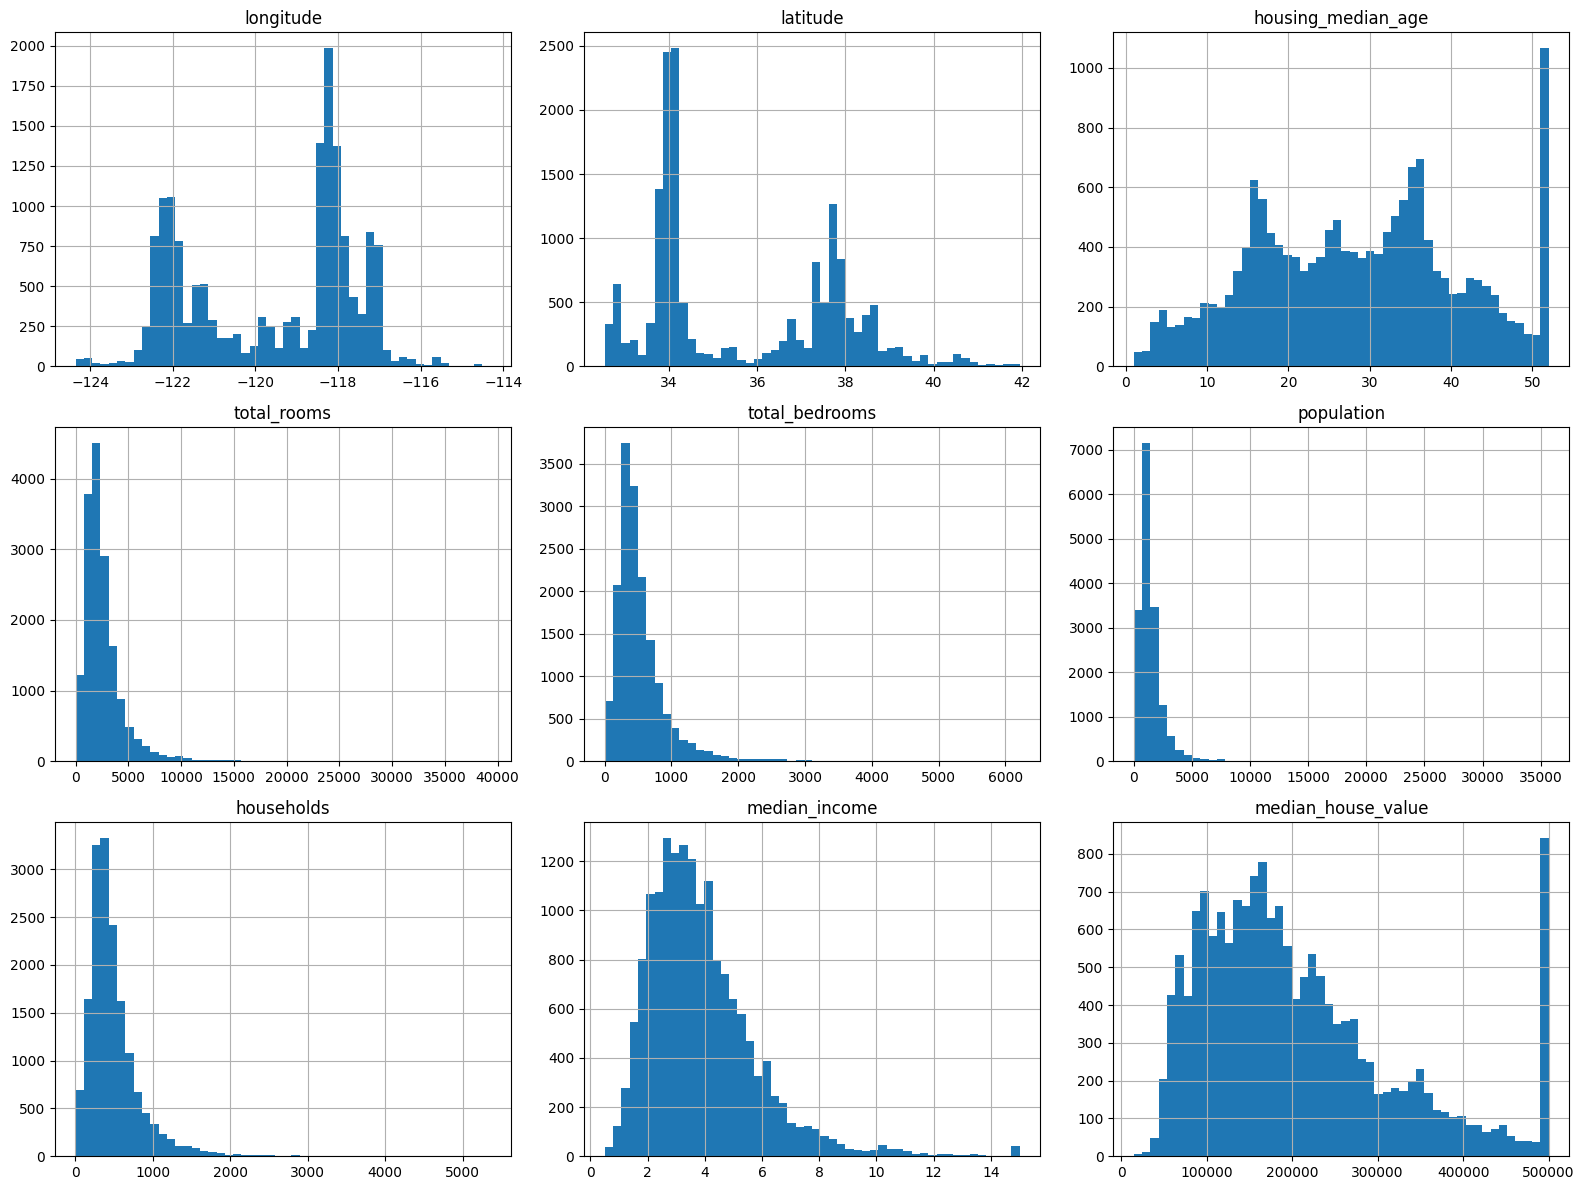

In [10]:
housing_train.hist(bins=50, figsize=(16, 12))
plt.tight_layout()
plt.show()


### 5.2 Target Distribution

The target column `median_house_value` is capped at 500,001 in this dataset.  
This cap can make prediction harder for expensive districts.


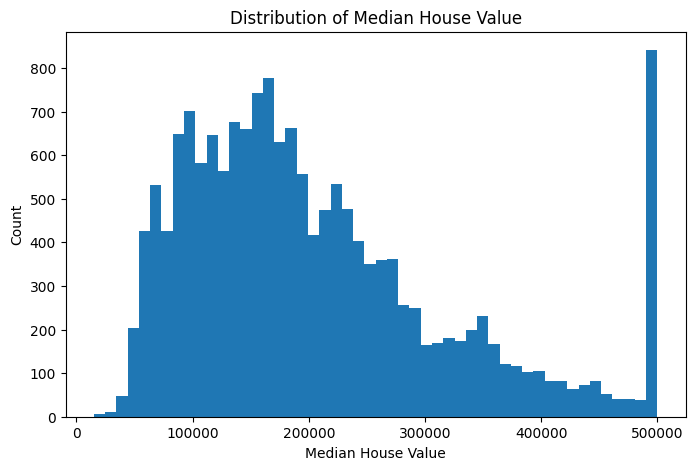

Maximum target value: 500001.0
Rows at cap: 809


In [11]:
plt.figure(figsize=(8, 5))
plt.hist(housing_train["median_house_value"], bins=50)
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.title("Distribution of Median House Value")
plt.show()

print("Maximum target value:", housing_train["median_house_value"].max())
print("Rows at cap:", (housing_train["median_house_value"] >= 500000).sum())


### 5.3 Geographic Visualization

Longitude and latitude show where districts are located.  
The color represents house value and the point size represents population.


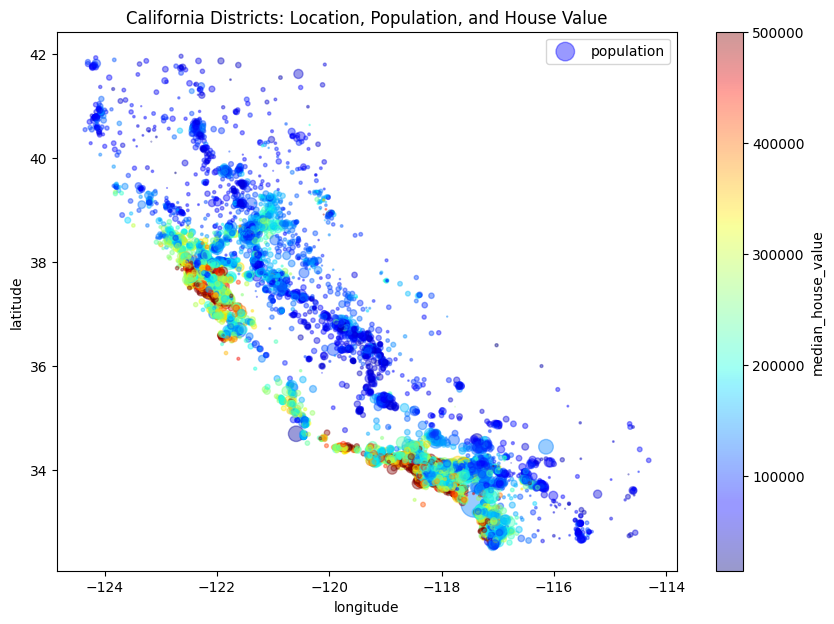

In [12]:
housing_train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing_train["population"] / 100,
    label="population",
    figsize=(10, 7),
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()
plt.title("California Districts: Location, Population, and House Value")
plt.show()


### 5.4 Correlation Analysis

Correlation gives a quick idea of which numeric features move with the target.


In [13]:
corr_matrix = housing_train.corr(numeric_only=True)
corr_with_target = corr_matrix["median_house_value"].sort_values(ascending=False)
corr_with_target


median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

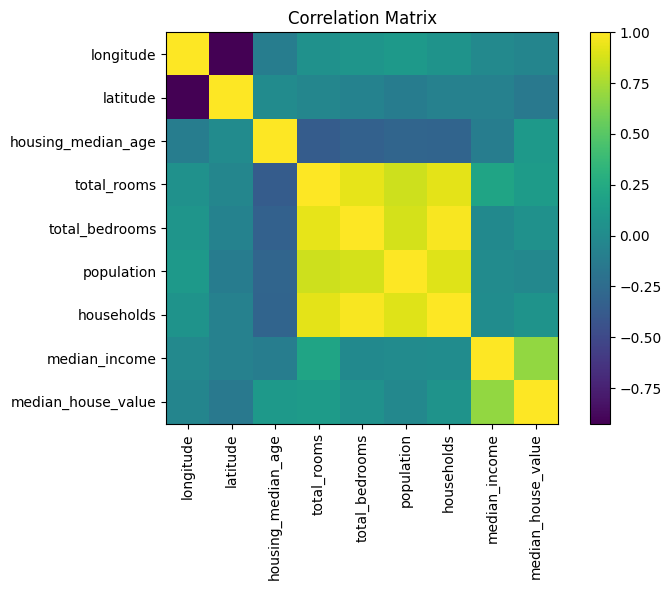

In [14]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### 5.5 Important Scatter Plots

`median_income` is usually the strongest predictor for `median_house_value`.


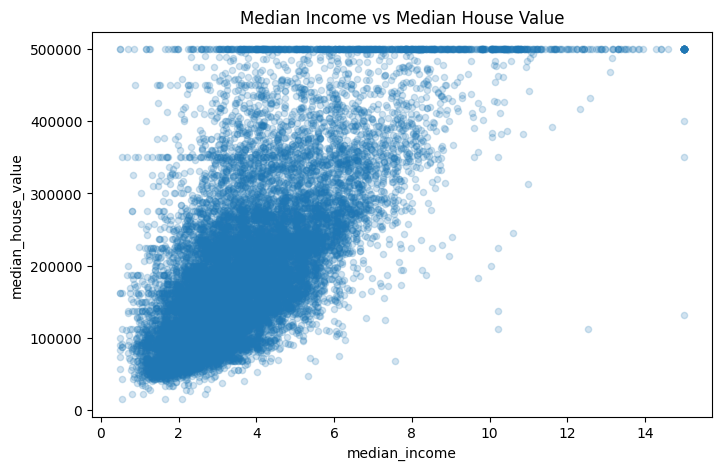

In [15]:
housing_train.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.2,
    figsize=(8, 5),
)
plt.title("Median Income vs Median House Value")
plt.show()


### 5.6 Create Useful Combined Features

Some original columns are totals per district.  
Ratios are often more meaningful:

- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`


In [16]:
housing_train["rooms_per_household"] = housing_train["total_rooms"] / housing_train["households"]
housing_train["bedrooms_per_room"] = housing_train["total_bedrooms"] / housing_train["total_rooms"]
housing_train["population_per_household"] = housing_train["population"] / housing_train["households"]

corr_matrix = housing_train.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)


median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

## 6. Prepare Data for Machine Learning

We separate features from the target.

Important preprocessing steps:

- Fill missing numeric values using median imputation
- Scale numeric features
- One-hot encode the categorical feature `ocean_proximity`
- Add custom ratio features inside the pipeline


In [17]:
housing_features = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

housing_test_features = strat_test_set.drop("median_house_value", axis=1)
housing_test_labels = strat_test_set["median_house_value"].copy()

print(housing_features.shape)
print(housing_labels.shape)


(16512, 9)
(16512,)


In [18]:
rooms_ix = housing_features.columns.get_loc("total_rooms")
bedrooms_ix = housing_features.columns.get_loc("total_bedrooms")
population_ix = housing_features.columns.get_loc("population")
households_ix = housing_features.columns.get_loc("households")


class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    # Add ratio features that are useful for housing price prediction.

    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        return np.c_[X, rooms_per_household, population_per_household]


In [19]:
num_attribs = list(housing_features.drop("ocean_proximity", axis=1).columns)
cat_attribs = ["ocean_proximity"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler()),
])

# Compatibility with different scikit-learn versions
try:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_encoder, cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing_features)
housing_prepared.shape


(16512, 16)

## 7. Train Baseline Models

We start with three models:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

We evaluate them using RMSE, MAE, and R² on the training set first.


In [20]:
def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

train_results = []

for name, model in models.items():
    model.fit(housing_prepared, housing_labels)
    predictions = model.predict(housing_prepared)
    rmse, mae, r2 = evaluate_predictions(housing_labels, predictions)
    train_results.append({
        "Model": name,
        "Train RMSE": rmse,
        "Train MAE": mae,
        "Train R²": r2,
    })

pd.DataFrame(train_results).sort_values("Train RMSE")


,Model,Train RMSE,Train MAE,Train R²
1,Decision Tree,0.000000,0.000000,1.000000
2,Random Forest,18650.698706,12061.519984,0.974014
0,Linear Regression,68627.873900,49438.668609,0.648155


## 8. Cross-Validation

Training-set performance can be misleading.  
Cross-validation gives a better estimate of how the model performs on unseen data.


In [21]:
def display_cv_scores(model, X, y, model_name, cv=10):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )
    rmse_scores = np.sqrt(-scores)
    return {
        "Model": model_name,
        "CV RMSE Mean": rmse_scores.mean(),
        "CV RMSE Std": rmse_scores.std(),
        "CV RMSE Min": rmse_scores.min(),
        "CV RMSE Max": rmse_scores.max(),
    }


cv_results = []
for name, model in models.items():
    cv_results.append(display_cv_scores(model, housing_prepared, housing_labels, name))

cv_results_df = pd.DataFrame(cv_results).sort_values("CV RMSE Mean")
cv_results_df


,Model,CV RMSE Mean,CV RMSE Std,CV RMSE Min,CV RMSE Max
2,Random Forest,50435.580921,2203.338141,47210.512698,54055.908946
0,Linear Regression,69104.079982,2880.328210,64114.991664,73997.080502
1,Decision Tree,71629.890097,2914.035468,68960.045444,79094.741237


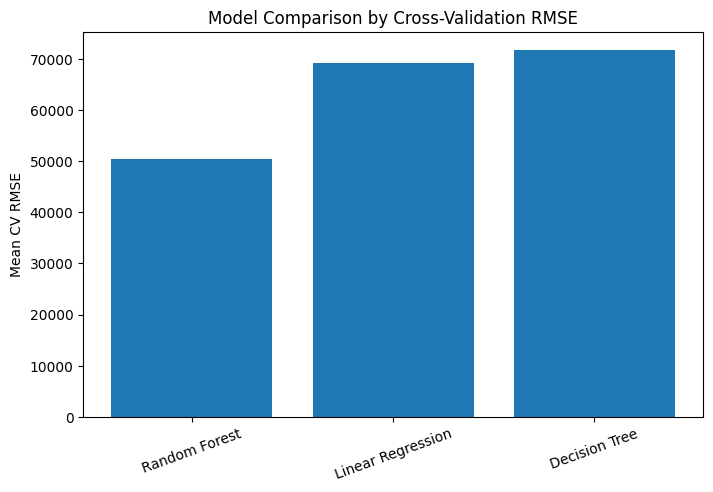

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(cv_results_df["Model"], cv_results_df["CV RMSE Mean"])
plt.ylabel("Mean CV RMSE")
plt.title("Model Comparison by Cross-Validation RMSE")
plt.xticks(rotation=20)
plt.show()


## 9. Hyperparameter Tuning

Random Forest usually performs better for this dataset, so we tune it.

`RandomizedSearchCV` is faster than trying every possible combination, while still testing many useful options.


In [23]:
param_distributions = {
    "n_estimators": [50, 100, 150, 200],
    "max_features": [2, 4, 6, 8, 10],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

forest_reg = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

random_search = RandomizedSearchCV(
    forest_reg,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
)

random_search.fit(housing_prepared, housing_labels)

print("Best parameters:")
print(random_search.best_params_)
print("Best CV RMSE:", np.sqrt(-random_search.best_score_))


Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 6, 'max_depth': 30}
Best CV RMSE: 49333.18561037395


In [24]:
cvres = random_search.cv_results_
search_results = pd.DataFrame({
    "Mean CV RMSE": np.sqrt(-cvres["mean_test_score"]),
    "Std CV RMSE": cvres["std_test_score"],
    "Parameters": cvres["params"],
}).sort_values("Mean CV RMSE")

search_results.head(10)


,Mean CV RMSE,Std CV RMSE,Parameters
17,49333.185610,8.929051e+07,"{'n_estimators': 200, 'min_samples_split': 2, ..."
16,49419.135247,9.253666e+07,"{'n_estimators': 150, 'min_samples_split': 2, ..."
12,49453.825684,9.172971e+07,"{'n_estimators': 200, 'min_samples_split': 2, ..."
7,49620.055391,7.230081e+07,"{'n_estimators': 100, 'min_samples_split': 2, ..."
11,49733.711785,7.123896e+07,"{'n_estimators': 50, 'min_samples_split': 5, '..."
10,49737.146602,7.696744e+07,"{'n_estimators': 150, 'min_samples_split': 10,..."
4,49757.891563,7.868190e+07,"{'n_estimators': 100, 'min_samples_split': 10,..."
2,49759.594430,9.028160e+07,"{'n_estimators': 150, 'min_samples_split': 5, ..."
13,49958.023698,8.037250e+07,"{'n_estimators': 100, 'min_samples_split': 5, ..."
5,50320.523259,8.579391e+07,"{'n_estimators': 100, 'min_samples_split': 5, ..."


## 10. Feature Importance

Random Forest can show which features were most useful for prediction.


In [25]:
best_forest = random_search.best_estimator_

extra_attribs = ["rooms_per_household", "population_per_household", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.get_feature_names_out(cat_attribs))
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

feature_importances = pd.DataFrame({
    "Feature": attributes,
    "Importance": best_forest.feature_importances_,
}).sort_values("Importance", ascending=False)

feature_importances


,Feature,Importance
7,median_income,0.330796
12,ocean_proximity_INLAND,0.154431
9,population_per_household,0.110388
10,bedrooms_per_room,0.080314
0,longitude,0.073118
1,latitude,0.066823
8,rooms_per_household,0.062161
2,housing_median_age,0.041439
3,total_rooms,0.015542
5,population,0.015465


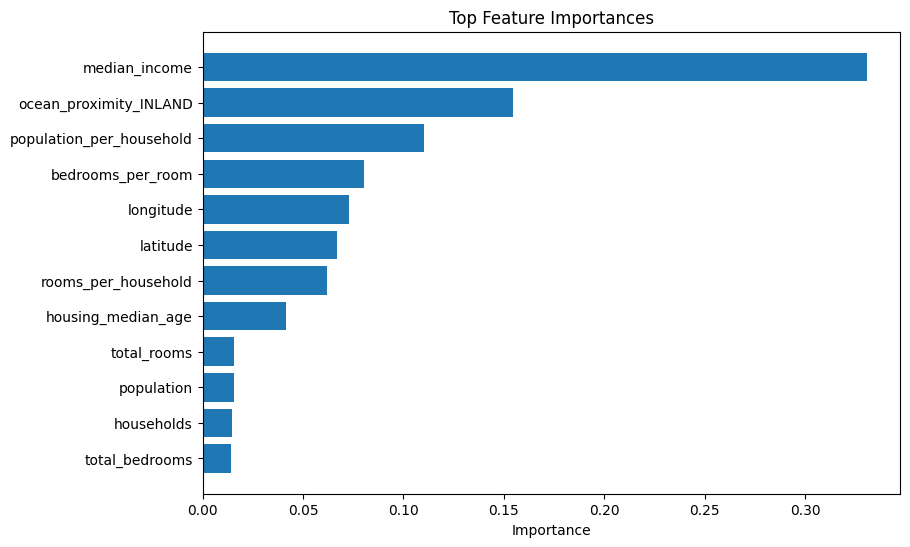

In [26]:
plt.figure(figsize=(9, 6))
top_features = feature_importances.head(12).sort_values("Importance")
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.show()


## 11. Final Evaluation on the Test Set

The test set must be used only once near the end.  
This gives the most honest estimate of real-world performance.


In [27]:
final_model = random_search.best_estimator_

X_test_prepared = full_pipeline.transform(housing_test_features)
final_predictions = final_model.predict(X_test_prepared)

final_rmse, final_mae, final_r2 = evaluate_predictions(housing_test_labels, final_predictions)

print(f"Final Test RMSE: {final_rmse:,.2f}")
print(f"Final Test MAE:  {final_mae:,.2f}")
print(f"Final Test R²:   {final_r2:.4f}")


Final Test RMSE: 46,970.48
Final Test MAE:  31,445.46
Final Test R²:   0.8307


In [28]:
comparison_df = pd.DataFrame({
    "Actual Price": housing_test_labels.values,
    "Predicted Price": final_predictions,
    "Error": housing_test_labels.values - final_predictions,
})

comparison_df.head(10)


,Actual Price,Predicted Price,Error
0,500001.0,484448.330750,15552.669250
1,162500.0,243353.723917,-80853.723917
2,204600.0,211416.625099,-6816.625099
3,159700.0,171517.102976,-11817.102976
4,184000.0,259052.707624,-75052.707624
5,151900.0,161626.579762,-9726.579762
6,104900.0,133939.653690,-29039.653690
7,500001.0,417604.651220,82396.348780
8,367400.0,239086.797024,128313.202976
9,346500.0,276671.276702,69828.723298


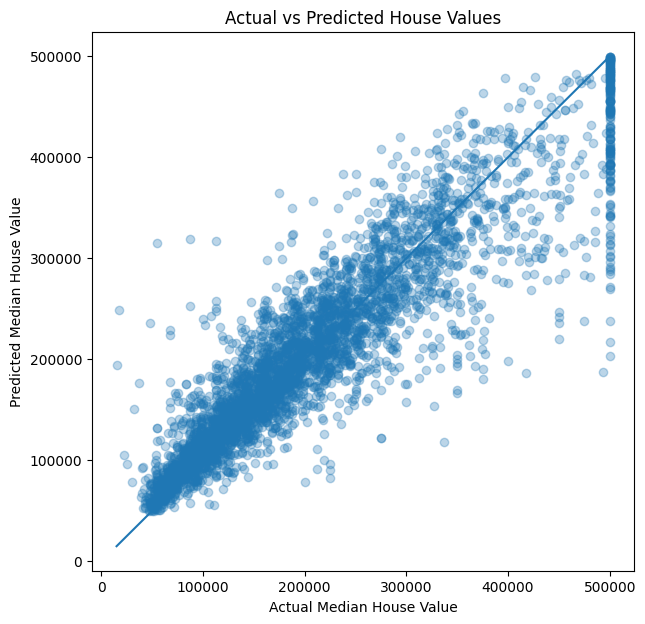

In [29]:
plt.figure(figsize=(7, 7))
plt.scatter(housing_test_labels, final_predictions, alpha=0.3)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Values")
plt.plot([housing_test_labels.min(), housing_test_labels.max()], [housing_test_labels.min(), housing_test_labels.max()])
plt.show()


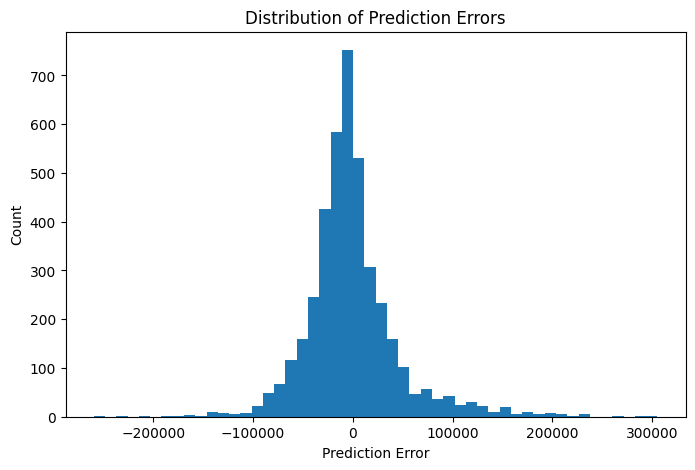

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(comparison_df["Error"], bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.show()


## 12. Save the Final Pipeline

We save both preprocessing and model together in one pipeline.  
This is important because future predictions must use the exact same preprocessing steps.


In [31]:
final_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", final_model),
])

MODEL_PATH = "house_price_model.pkl"
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")


Model saved to: house_price_model.pkl


## 13. Example Prediction

Use one row from the test set to verify that the saved pipeline can make predictions directly from raw input data.


In [32]:
loaded_model = joblib.load(MODEL_PATH)

sample_data = housing_test_features.iloc[:5]
sample_labels = housing_test_labels.iloc[:5]
sample_predictions = loaded_model.predict(sample_data)

pd.DataFrame({
    "Actual": sample_labels.values,
    "Predicted": sample_predictions,
    "Absolute Error": np.abs(sample_labels.values - sample_predictions),
})


,Actual,Predicted,Absolute Error
0,500001.0,484448.330750,15552.669250
1,162500.0,243353.723917,80853.723917
2,204600.0,211416.625099,6816.625099
3,159700.0,171517.102976,11817.102976
4,184000.0,259052.707624,75052.707624


## 14. Conclusion

### What we did
- Loaded and inspected the dataset
- Used stratified train/test splitting based on income category
- Performed EDA with distributions, geographic plots, correlations, and scatter plots
- Added useful engineered features
- Built a preprocessing pipeline for numeric and categorical columns
- Compared Linear Regression, Decision Tree, and Random Forest models
- Tuned Random Forest using randomized search
- Evaluated the final model on the test set
- Saved the final model pipeline for future use

### Main lesson
A complete ML project is not only about training a model.  
Good splitting, EDA, preprocessing, validation, and final testing are what make the result reliable.
